In [26]:
import pandas as pd

In [29]:
#Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [30]:
df.shape

(1470, 35)

In [31]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [32]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [33]:
df.groupby("Department")["Attrition"].value_counts()

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

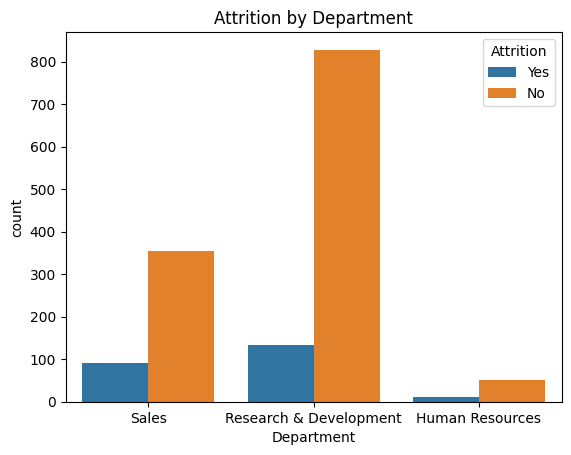

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Attrition by Department
sns.countplot(data=df, x='Department', hue='Attrition')
plt.title('Attrition by Department')
plt.show()



Does low job satisfaction predict attrition?

In [35]:
df.groupby("JobSatisfaction")["Attrition"].value_counts()

JobSatisfaction  Attrition
1                No           223
                 Yes           66
2                No           234
                 Yes           46
3                No           369
                 Yes           73
4                No           407
                 Yes           52
Name: count, dtype: int64

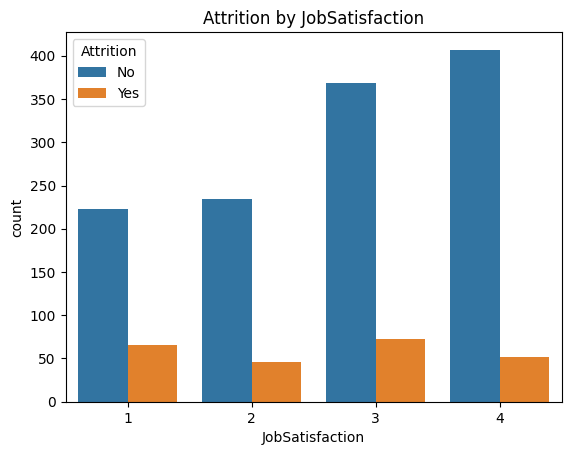

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Attrition by Department
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition')
plt.title('Attrition by JobSatisfaction')
plt.show()


Does monthly income affect attrition? 

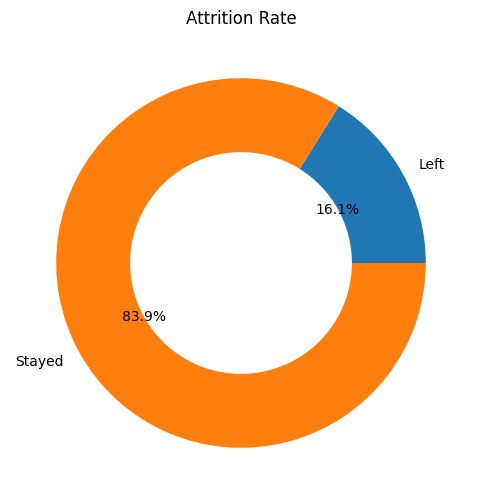

In [14]:
import matplotlib.pyplot as plt

labels = ['Left', 'Stayed']
sizes = [237, 1233]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    wedgeprops={'width':0.4}
)

plt.title("Attrition Rate")

plt.show()

Claud 

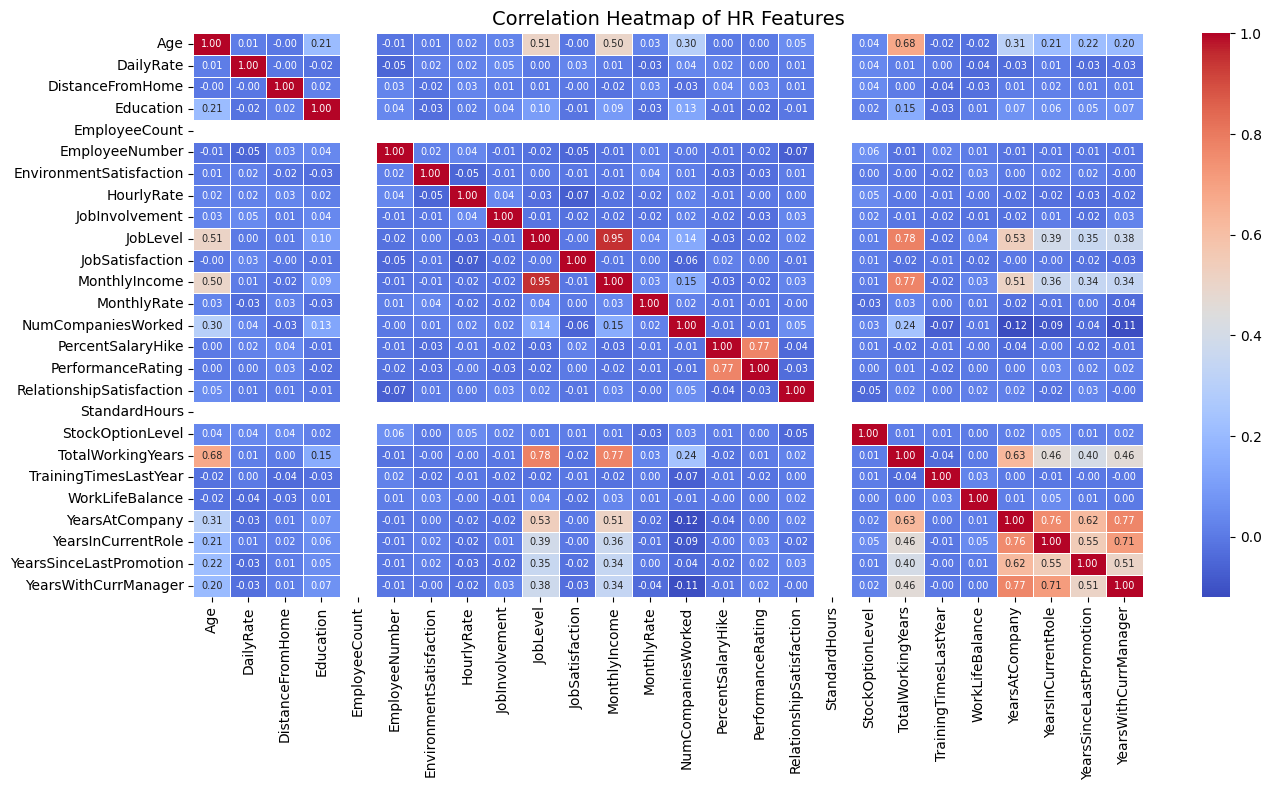

In [37]:
plt.figure(figsize=(14, 8))

# Select numeric columns only
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 7})

plt.title("Correlation Heatmap of HR Features", fontsize=14)
plt.tight_layout()
plt.show()

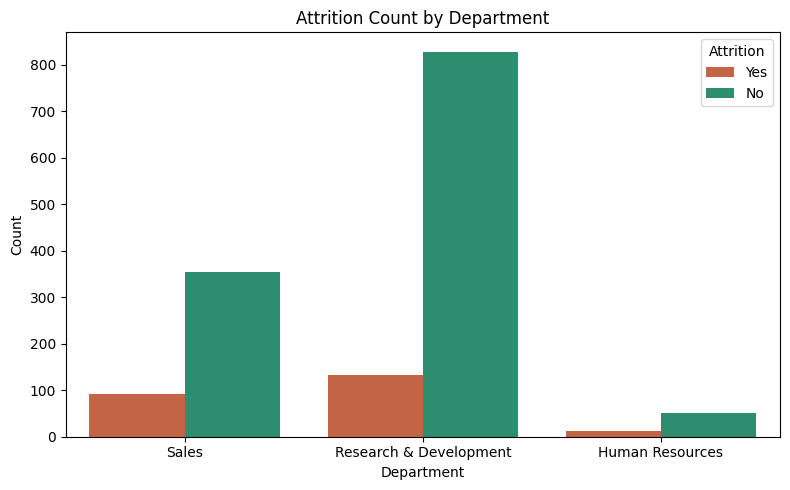

In [38]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Department', hue='Attrition',
              palette={'Yes': '#D85A30', 'No': '#1D9E75'})

plt.title("Attrition Count by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

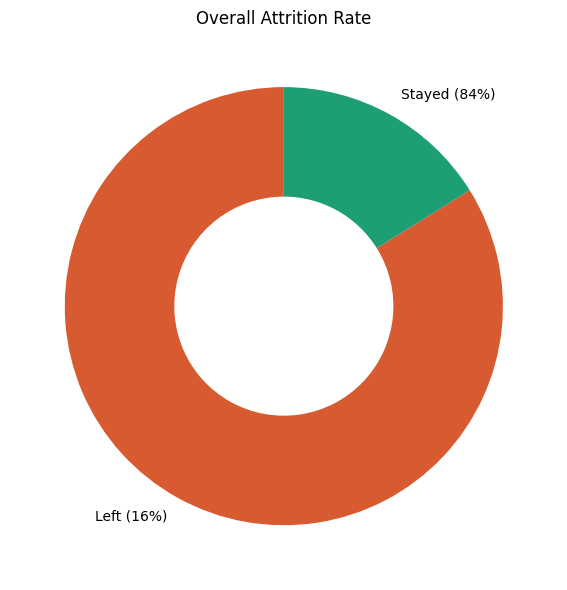

In [56]:
attrition_counts = df['Attrition'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(attrition_counts,
       labels=[f'Left ({attrition_counts["Yes"]/len(df)*100:.0f}%)',
               f'Stayed ({attrition_counts["No"]/len(df)*100:.0f}%)'],
       colors=['#D85A30', '#1D9E75'],
       startangle=90,
       wedgeprops=dict(width=0.5))  # makes it a donut

plt.title("Overall Attrition Rate")
plt.tight_layout()
plt.show()

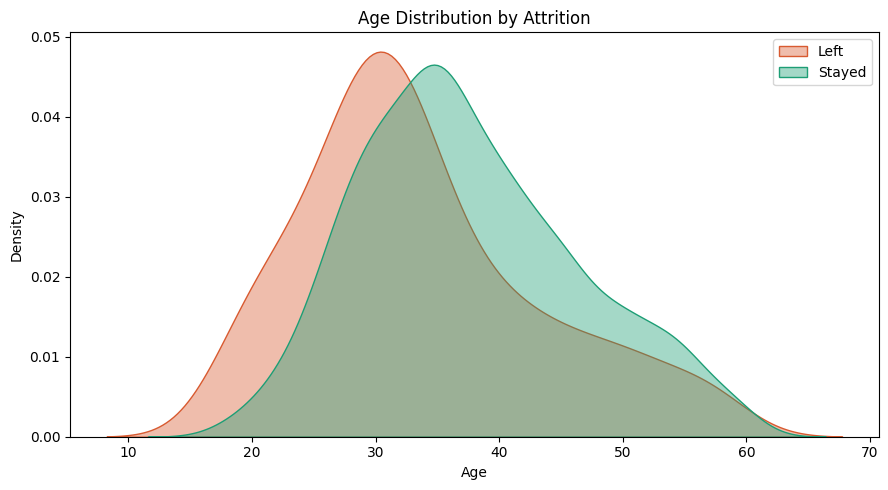

In [42]:
plt.figure(figsize=(9, 5))

sns.kdeplot(data=df[df['Attrition'] == 'Yes']['Age'],
            label='Left', color='#D85A30', fill=True, alpha=0.4)

sns.kdeplot(data=df[df['Attrition'] == 'No']['Age'],
            label='Stayed', color='#1D9E75', fill=True, alpha=0.4)

plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

/tmp/ipykernel_7095/3148116243.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',


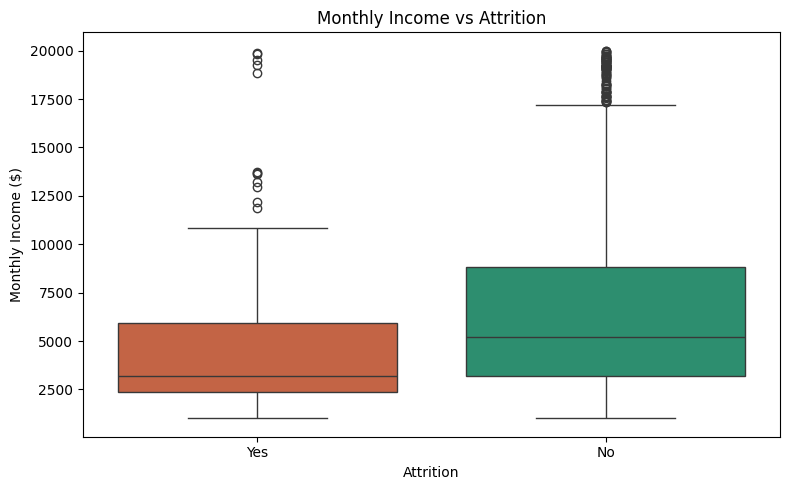

In [43]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            palette={'Yes': '#D85A30', 'No': '#1D9E75'})

plt.title("Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income ($)")
plt.tight_layout()
plt.show()

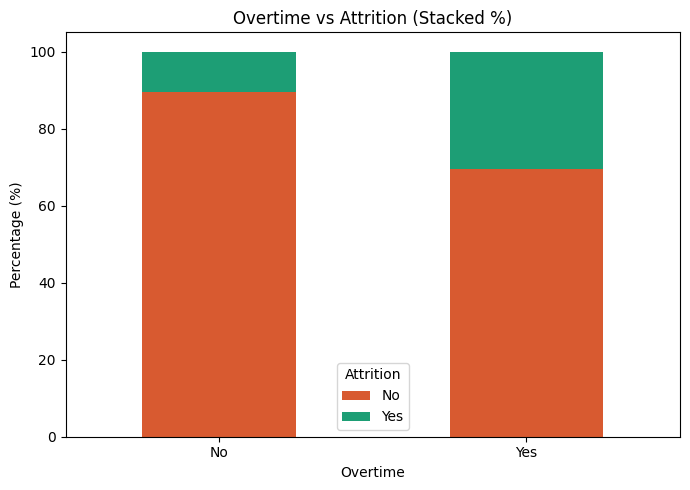

In [44]:
overtime_df = df.groupby(['OverTime', 'Attrition']).size().unstack()
overtime_pct = overtime_df.div(overtime_df.sum(axis=1), axis=0) * 100

overtime_pct.plot(kind='bar', stacked=True,
                  color=['#D85A30', '#1D9E75'],
                  figsize=(7, 5))

plt.title("Overtime vs Attrition (Stacked %)")
plt.xlabel("Overtime")
plt.ylabel("Percentage (%)")
plt.legend(title="Attrition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

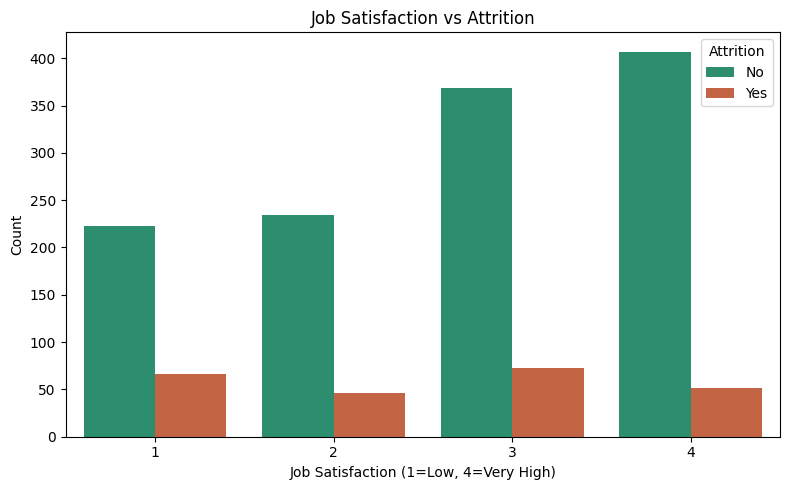

In [45]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='JobSatisfaction', hue='Attrition',
              palette={'Yes': '#D85A30', 'No': '#1D9E75'})

plt.title("Job Satisfaction vs Attrition")
plt.xlabel("Job Satisfaction (1=Low, 4=Very High)")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

/tmp/ipykernel_7095/3290732072.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Attrition', y='YearsAtCompany',


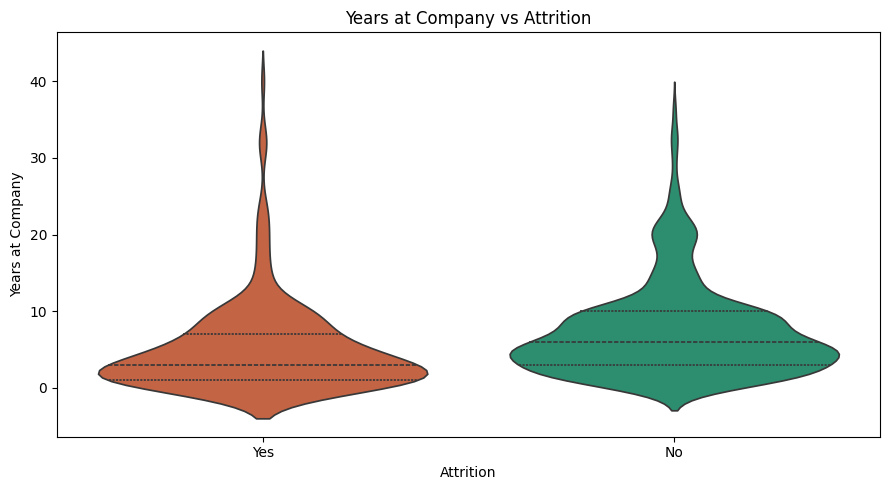

In [46]:
plt.figure(figsize=(9, 5))

sns.violinplot(data=df, x='Attrition', y='YearsAtCompany',
               palette={'Yes': '#D85A30', 'No': '#1D9E75'},
               inner='quartile')

plt.title("Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.tight_layout()
plt.show()

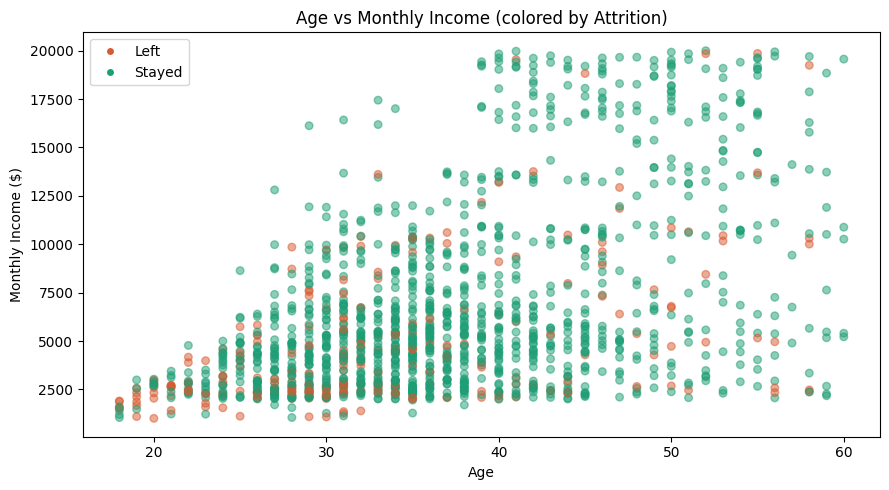

In [47]:
plt.figure(figsize=(9, 5))

colors = df['Attrition'].map({'Yes': '#D85A30', 'No': '#1D9E75'})

plt.scatter(df['Age'], df['MonthlyIncome'],
            c=colors, alpha=0.5, s=30)

plt.title("Age vs Monthly Income (colored by Attrition)")
plt.xlabel("Age")
plt.ylabel("Monthly Income ($)")

# Manual legend
from matplotlib.lines import Line2D
legend = [Line2D([0],[0], marker='o', color='w',
                 markerfacecolor='#D85A30', label='Left'),
          Line2D([0],[0], marker='o', color='w',
                 markerfacecolor='#1D9E75', label='Stayed')]
plt.legend(handles=legend)
plt.tight_layout()
plt.show()

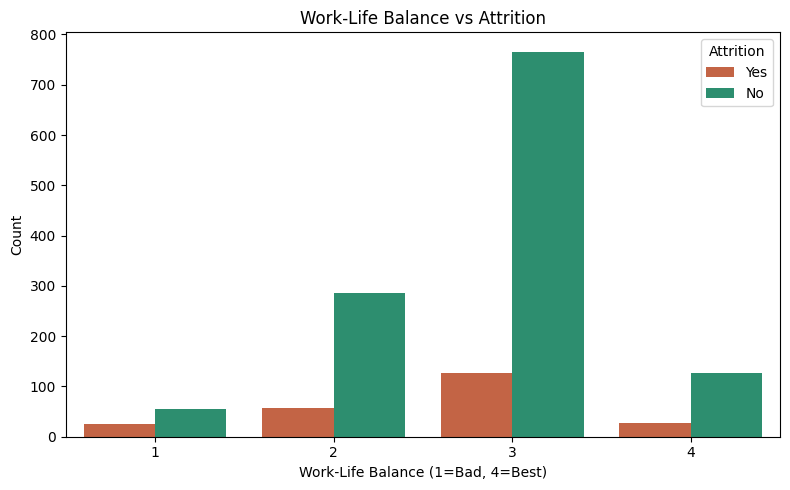

In [48]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='WorkLifeBalance', hue='Attrition',
              palette={'Yes': '#D85A30', 'No': '#1D9E75'})

plt.title("Work-Life Balance vs Attrition")
plt.xlabel("Work-Life Balance (1=Bad, 4=Best)")
plt.ylabel("Count")
plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

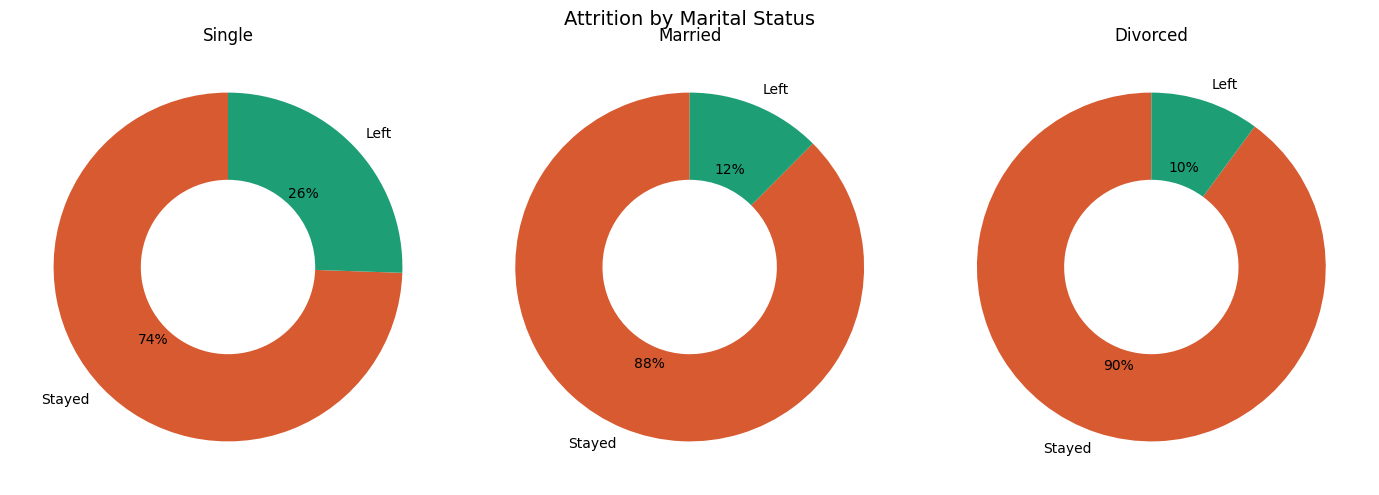

In [53]:
marital_groups = df.groupby(['MaritalStatus', 'Attrition']).size().unstack()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, status in enumerate(['Single', 'Married', 'Divorced']):
    values = marital_groups.loc[status]
    axes[i].pie(values,
                labels=['Stayed', 'Left'],
                colors=['#D85A30', '#1D9E75'],
                autopct='%1.0f%%',
                startangle=90,
                wedgeprops=dict(width=0.5))
    axes[i].set_title(status)

plt.suptitle("Attrition by Marital Status", fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
df['Attrition_Num'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

In [51]:
print("Dataset loaded:", df.shape)

Dataset loaded: (1470, 36)


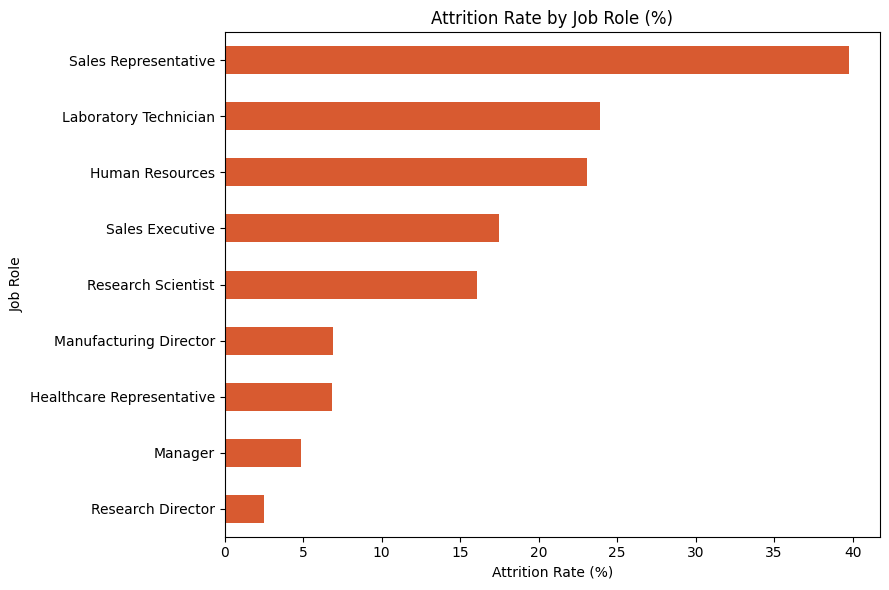

In [52]:
# ✅ Use Attrition_Num instead of Attrition
role_attr = df.groupby('JobRole')['Attrition_Num'].mean() * 100
role_attr = role_attr.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
role_attr.plot(kind='barh', color='#D85A30')

plt.title("Attrition Rate by Job Role (%)")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()